# 1. Time Series Review
# Plot monthly mean discharge and concentration for two hydrological stations

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA

In [2]:
#Change root to your folder path
#root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
root = r'C:\Users\Sylvie\OneDrive\ETH\Master\2_Semester\Lab_WRM\2_ex\DATA\DATA'
qD = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'), parse_dates=['timestamp']).set_index('timestamp')
qG = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'), parse_dates=['timestamp']).set_index('timestamp')
sscD = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'), parse_dates=['timestamp']).set_index('timestamp')
sscG = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')

In [3]:
display(qD.head(2))
display(qG.head(2))
display(sscD.head(2))
display(sscG.head(2))

,q_m3s
timestamp,
1984-01-01 00:00:00,113.081
1984-01-01 00:10:00,113.044


,q_m3s
timestamp,
1976-01-01 00:15:00,18.8
1976-01-01 00:30:00,18.7


,ssc_gL
timestamp,
2012-01-01 00:00:00,0.01785
2012-01-01 00:10:00,NaN


,ssc_gL
timestamp,
2004-01-01 00:00:00,0.0153
2004-01-01 00:15:00,0.0143


In [4]:
#monthly means
qD = qD.resample('ME').mean()
qG = qG.resample('ME').mean()
sscD = sscD.resample('ME').mean()
sscG = sscG.resample('ME').mean()

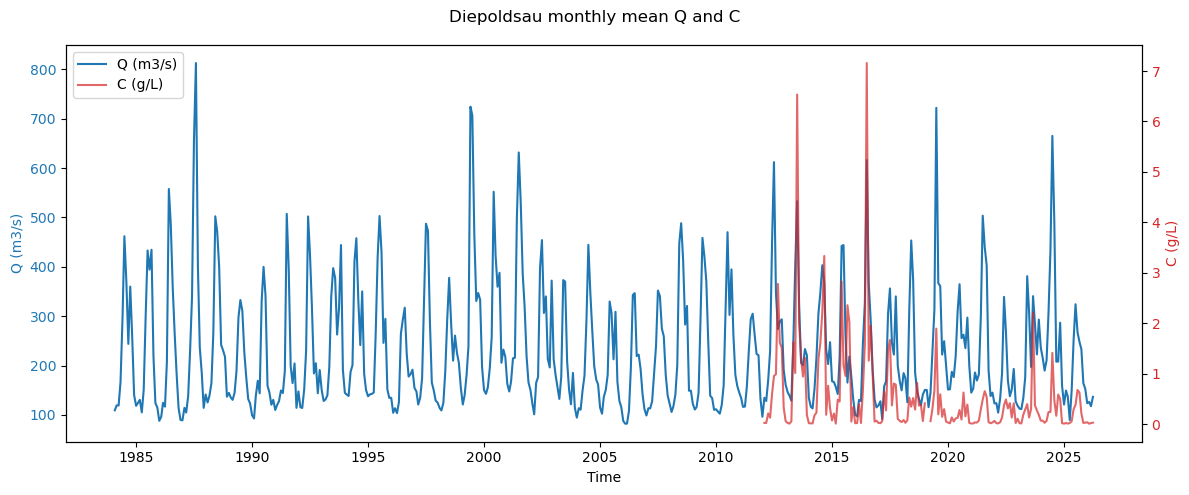

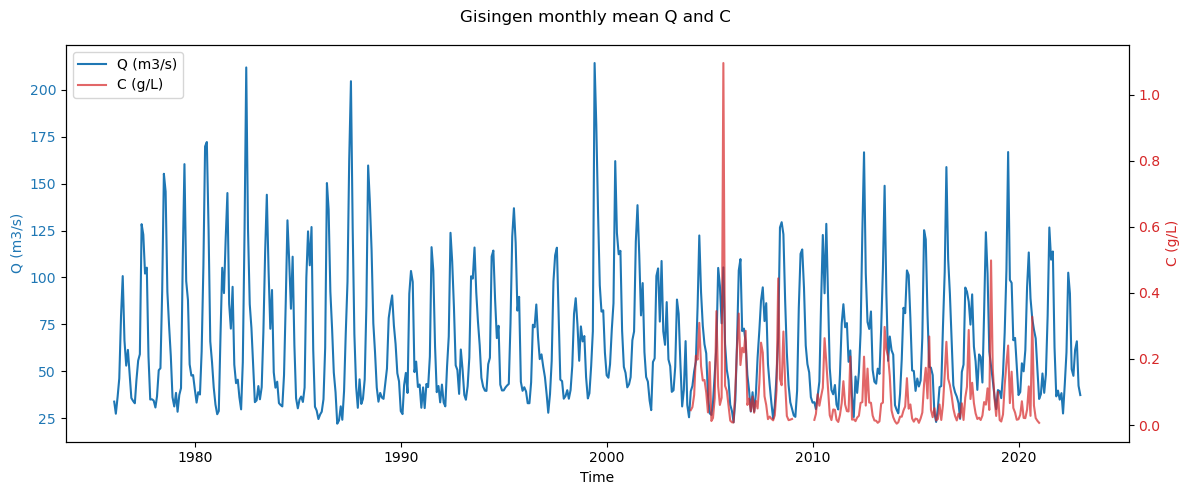

In [5]:
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(dfQ.index, dfQ['q_m3s'], label='Q (m3/s)', color='tab:blue')
    ax.set_xlabel('Time')
    ax.set_ylabel('Q (m3/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:,0], label='C (g/L)', color='tab:red', alpha=0.7)
    ax2.set_ylabel('C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')
    fig.suptitle(f'{station} monthly mean Q and C')
    fig.tight_layout()
    plt.show()

# 1.2 Stationarity test and trend removal
This section fits a linear trend to each station's monthly mean discharge (Q) and concentration (C) series, tests the slope significance at the 5% level, removes any statistically significant trend, and verifies that the detrended series has zero mean and finite variance.

Diepoldsau Q: n=507, slope=-0.019002, p=0.6136, significant=False
    detrend method = mean
    mean after detrending = -2.421731e-14
    variance after detrending = 1.533543e+04

Diepoldsau C: n=169, slope=-0.006028, p=0.0000, significant=True
    detrend method = linear trend
    mean after detrending = -8.146015e-17
    variance after detrending = 7.961486e-01

Gisingen Q: n=564, slope=-0.007518, p=0.3952, significant=False
    detrend method = mean
    mean after detrending = 7.710145e-15
    variance after detrending = 1.166312e+03

Gisingen C: n=192, slope=-0.000396, p=0.0076, significant=True
    detrend method = linear trend
    mean after detrending = 2.370789e-17
    variance after detrending = 1.265569e-02



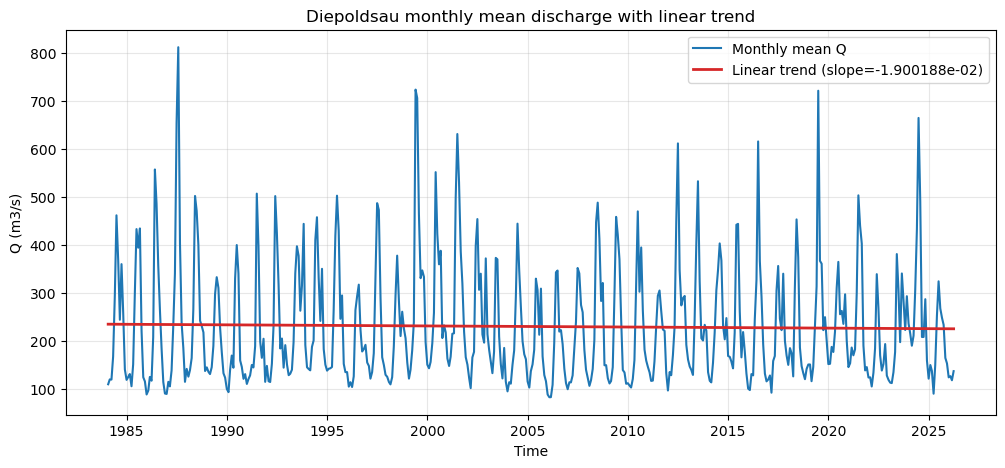

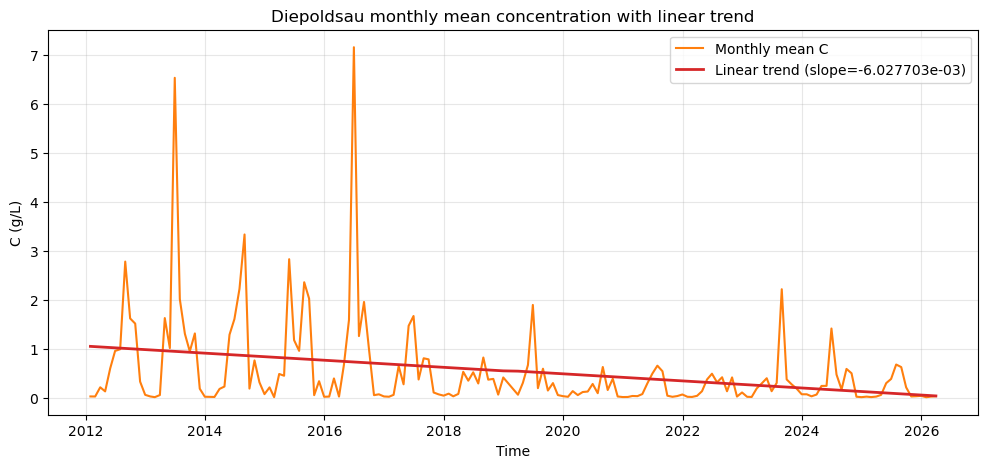

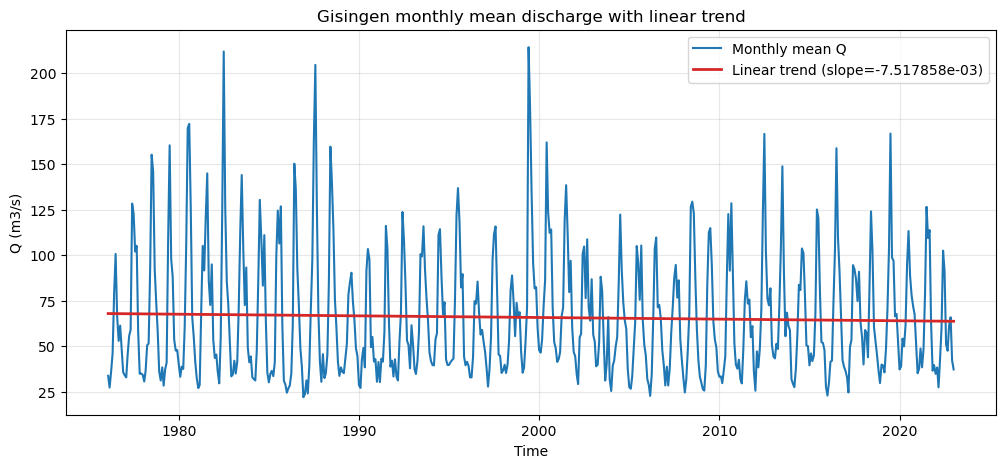

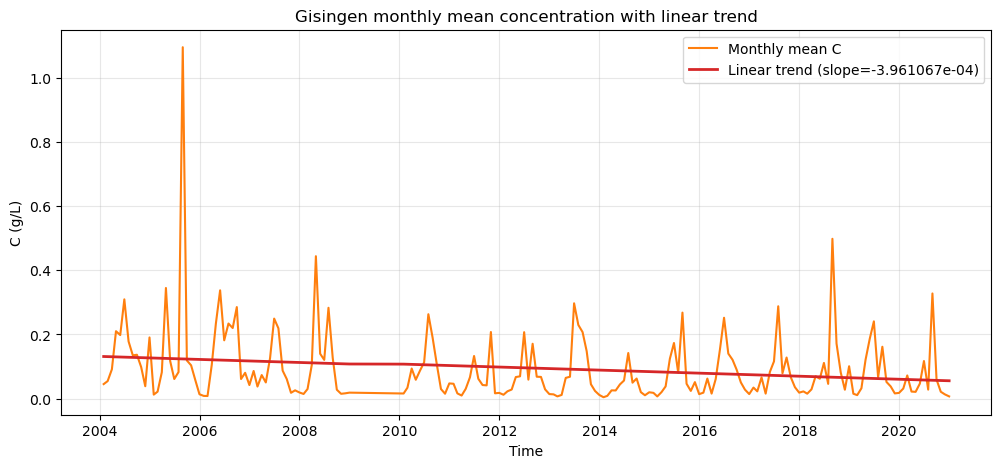

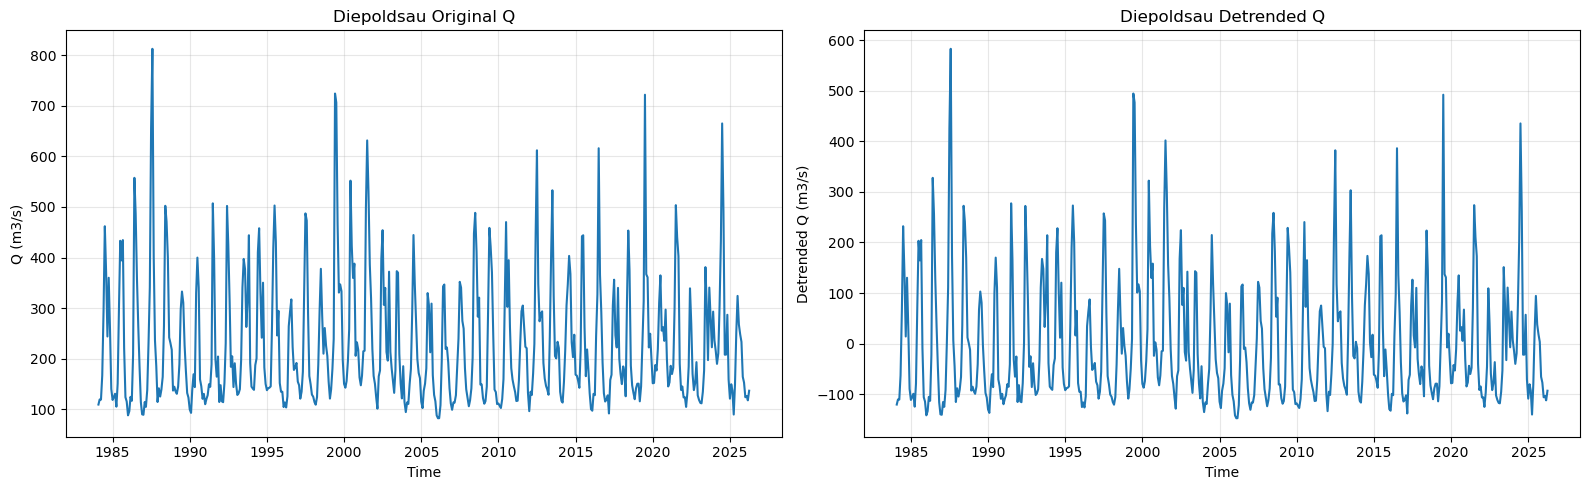

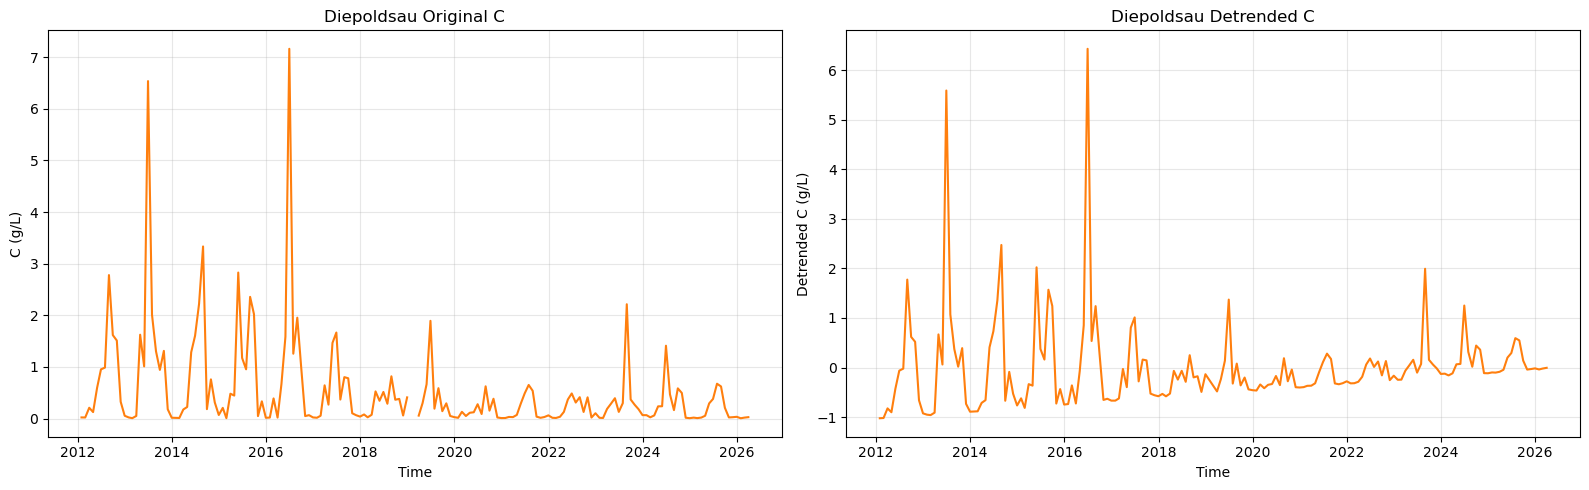

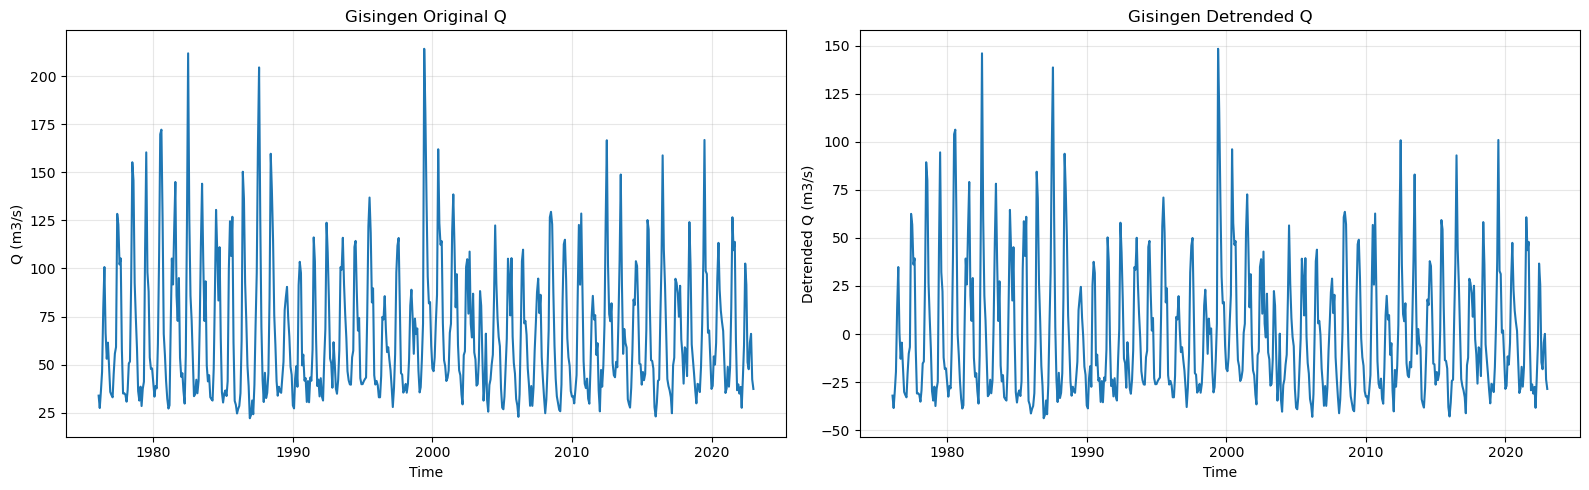

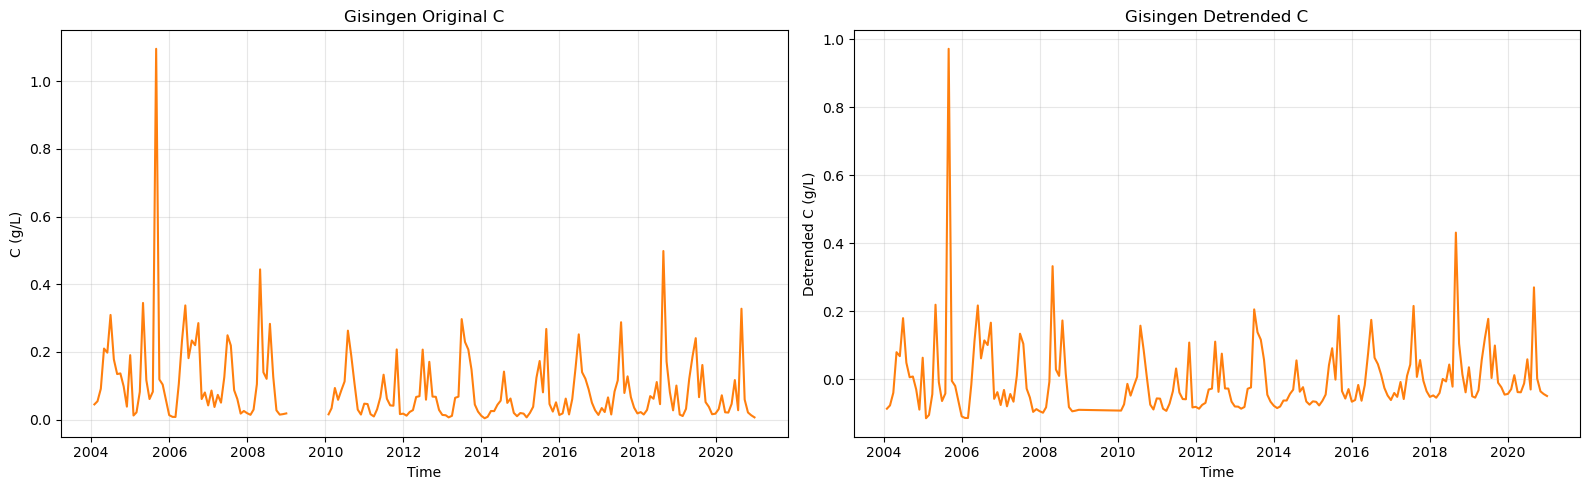

In [ ]:
def test_and_detrend(df, column_name):

    y = df[column_name].dropna()
    x = np.arange(len(y))
    trend = linregress(x, y.values)
    pvalue = trend.pvalue
    significant = pvalue < 0.05
    if significant:
        detrended = y.values - (trend.intercept + trend.slope * x)
        detrend_method = 'linear trend'
    else:
        detrended = y.values - y.values.mean()
        detrend_method = 'mean'
    detrended_mean = detrended.mean()
    detrended_var = detrended.var(ddof=1)
    detrended_series = pd.Series(detrended, index=y.index)
    
    results = {
        'n_points': len(y),
        'slope': trend.slope,
        'pvalue': pvalue,
        'significant': significant,
        'detrend_method': detrend_method,
        'mean_after_detrend': detrended_mean,
        'variance_after_detrend': detrended_var,
    }
    return detrended_series, results

station_results = []
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    # Detrend Q
    detrended_Q, results_Q = test_and_detrend(dfQ, 'q_m3s')
    detrended_series[f'Q_{station}'] = detrended_Q
    station_results.append({
        'station': station,
        'variable': 'Q',
        **results_Q
    })
    print(f"{station} Q: n={results_Q['n_points']}, slope={results_Q['slope']:.6f}, p={results_Q['pvalue']:.4f}, significant={results_Q['significant']}")
    print(f"    detrend method = {results_Q['detrend_method']}")
    print(f"    mean after detrending = {results_Q['mean_after_detrend']:.6e}")
    print(f"    variance after detrending = {results_Q['variance_after_detrend']:.6e}\n")
    
    # Detrend C (SSC)
    detrended_C, results_C = test_and_detrend(dfC, dfC.columns[0])
    detrended_series[f'C_{station}'] = detrended_C
    station_results.append({
        'station': station,
        'variable': 'C',
        **results_C
    })
    print(f"{station} C: n={results_C['n_points']}, slope={results_C['slope']:.6f}, p={results_C['pvalue']:.4f}, significant={results_C['significant']}")
    print(f"    detrend method = {results_C['detrend_method']}")
    print(f"    mean after detrending = {results_C['mean_after_detrend']:.6e}")
    print(f"    variance after detrending = {results_C['variance_after_detrend']:.6e}\n")

station_results_df = pd.DataFrame(station_results)
station_results_df

# Plot linear regression fit for each station and variable
for station, dfQ, dfC in [('Diepoldsau', qD, sscD), ('Gisingen', qG, sscG)]:
    # Plot for Q
    yQ = dfQ['q_m3s'].dropna()
    xQ = np.arange(len(yQ))
    trendQ = linregress(xQ, yQ.values)
    fittedQ = trendQ.intercept + trendQ.slope * xQ

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yQ.index, yQ, label='Monthly mean Q', color='tab:blue')
    ax.plot(yQ.index, fittedQ, label=f'Linear trend (slope={trendQ.slope:.6e})', color='tab:red', linewidth=2)
    ax.set_title(f'{station} monthly mean discharge with linear trend')
    ax.set_xlabel('Time')
    ax.set_ylabel('Q (m3/s)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()
    
    # Plot for C
    yC = dfC.iloc[:,0].dropna()
    xC = np.arange(len(yC))
    trendC = linregress(xC, yC.values)
    fittedC = trendC.intercept + trendC.slope * xC

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(yC.index, yC, label='Monthly mean C', color='tab:orange')
    ax.plot(yC.index, fittedC, label=f'Linear trend (slope={trendC.slope:.6e})', color='tab:red', linewidth=2)
    ax.set_title(f'{station} monthly mean concentration with linear trend')
    ax.set_xlabel('Time')
    ax.set_ylabel('C (g/L)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.show()

# Plot original vs detrended series
for station in ['Diepoldsau', 'Gisingen']:
    for variable in ['Q', 'C']:
        if variable == 'Q':
            original = qD if station == 'Diepoldsau' else qG
            original_col = 'q_m3s'
            ylabel = 'Q (m3/s)'
            color = 'tab:blue'
        else:
            original = sscD if station == 'Diepoldsau' else sscG
            original_col = original.columns[0]
            ylabel = 'C (g/L)'
            color = 'tab:orange'
        detrended = detrended_series[f'{variable}_{station}']
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
        
        # Original
        ax1.plot(original.index, original[original_col], color=color)
        ax1.set_title(f'{station} Original {variable}')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(ylabel)
        ax1.grid(True, alpha=0.3)
        
        # Detrended
        ax2.plot(detrended.index, detrended, color=color)
        ax2.set_title(f'{station} Detrended {variable}')
        ax2.set_xlabel('Time')
        ax2.set_ylabel(f'Detrended {ylabel}')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 2. Empirical Autocorrelation and partial autocorrelation analysis
This cell computes the empirical autocorrelation function (ACF) and the partial autocorrelation function (PACF) for the detrended discharge (Q) and concentration (C) series of each station, together with approximate 95% confidence intervals.

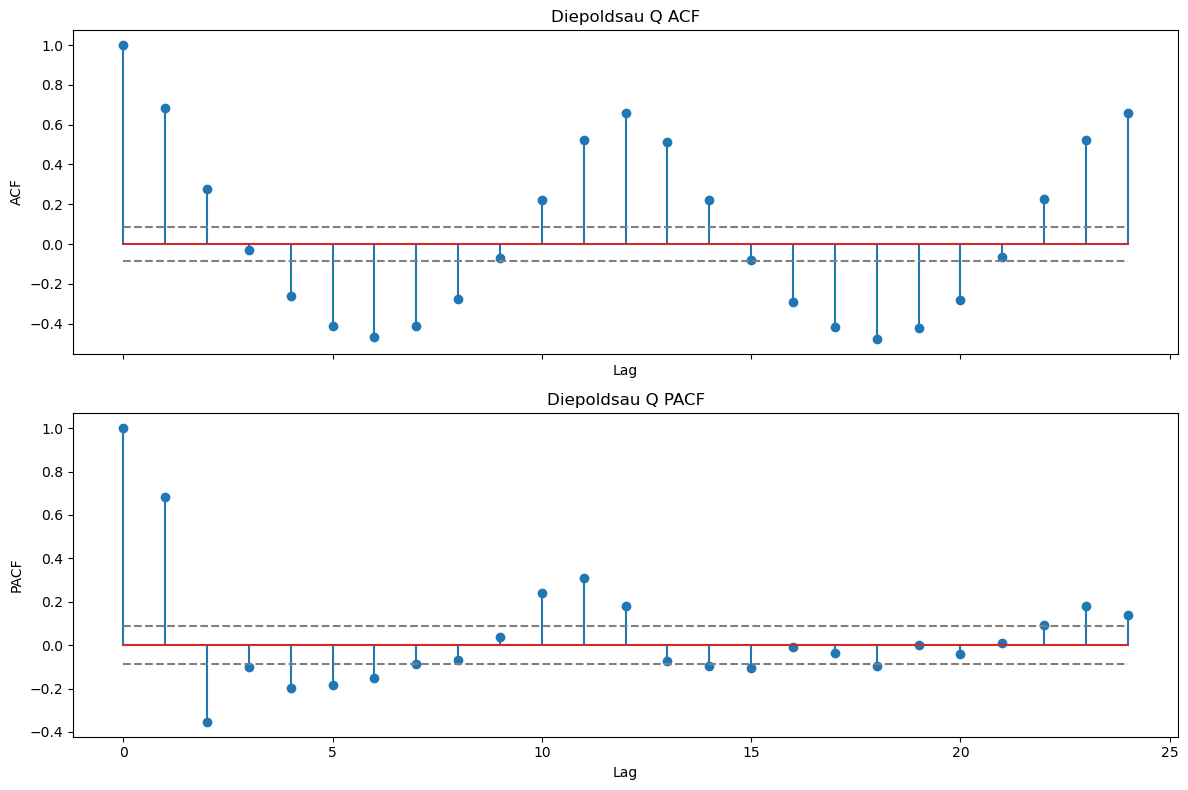

'Diepoldsau Q'

,lag,acf,acf_lower,acf_upper,pacf,pacf_lower,pacf_upper
0,0,1.000000,-0.087047,0.087047,1.000000,-0.087047,0.087047
1,1,0.683817,-0.087047,0.087047,0.683817,-0.087047,0.087047
2,2,0.279096,-0.087047,0.087047,-0.354077,-0.087047,0.087047
3,3,-0.030764,-0.087047,0.087047,-0.101078,-0.087047,0.087047
4,4,-0.259522,-0.087047,0.087047,-0.195964,-0.087047,0.087047
5,5,-0.410313,-0.087047,0.087047,-0.181626,-0.087047,0.087047
6,6,-0.465959,-0.087047,0.087047,-0.152953,-0.087047,0.087047
7,7,-0.410583,-0.087047,0.087047,-0.088888,-0.087047,0.087047
8,8,-0.274221,-0.087047,0.087047,-0.066785,-0.087047,0.087047
9,9,-0.069570,-0.087047,0.087047,0.039517,-0.087047,0.087047


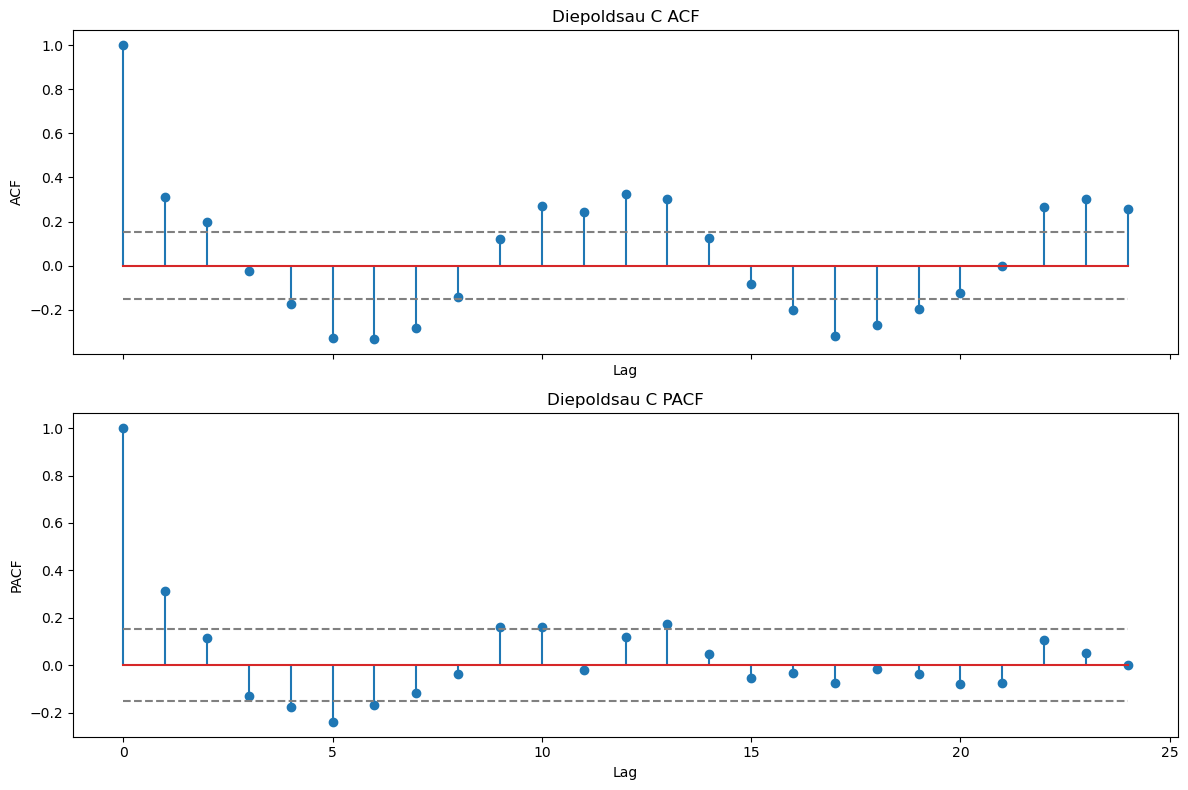

'Diepoldsau C'

,lag,acf,acf_lower,acf_upper,pacf,pacf_lower,pacf_upper
0,0,1.000000,-0.150769,0.150769,1.000000,-0.150769,0.150769
1,1,0.312752,-0.150769,0.150769,0.312752,-0.150769,0.150769
2,2,0.199457,-0.150769,0.150769,0.112664,-0.150769,0.150769
3,3,-0.023916,-0.150769,0.150769,-0.128551,-0.150769,0.150769
4,4,-0.172974,-0.150769,0.150769,-0.177364,-0.150769,0.150769
5,5,-0.325043,-0.150769,0.150769,-0.239871,-0.150769,0.150769
6,6,-0.331576,-0.150769,0.150769,-0.167820,-0.150769,0.150769
7,7,-0.279894,-0.150769,0.150769,-0.115592,-0.150769,0.150769
8,8,-0.140701,-0.150769,0.150769,-0.035950,-0.150769,0.150769
9,9,0.121265,-0.150769,0.150769,0.159393,-0.150769,0.150769


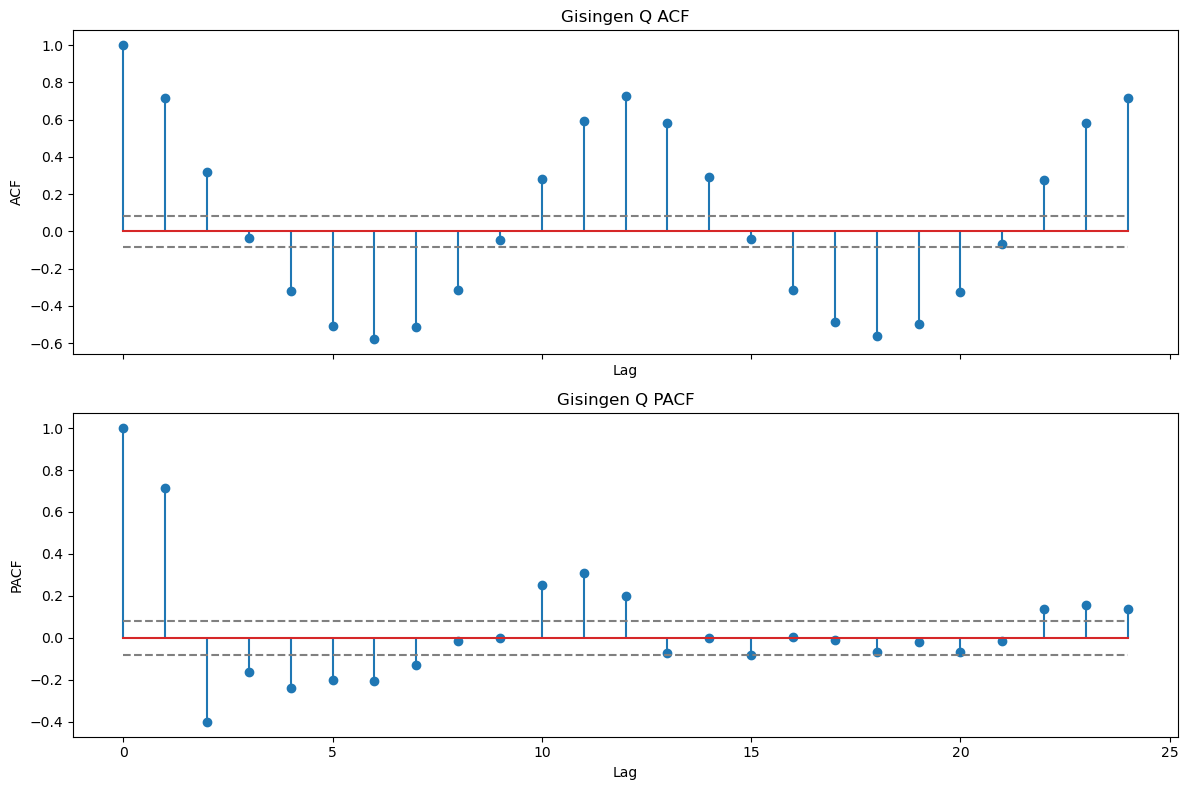

'Gisingen Q'

,lag,acf,acf_lower,acf_upper,pacf,pacf_lower,pacf_upper
0,0,1.000000,-0.082531,0.082531,1.000000,-0.082531,0.082531
1,1,0.716660,-0.082531,0.082531,0.716660,-0.082531,0.082531
2,2,0.318360,-0.082531,0.082531,-0.401405,-0.082531,0.082531
3,3,-0.035066,-0.082531,0.082531,-0.164533,-0.082531,0.082531
4,4,-0.321754,-0.082531,0.082531,-0.241206,-0.082531,0.082531
5,5,-0.506854,-0.082531,0.082531,-0.200094,-0.082531,0.082531
6,6,-0.576980,-0.082531,0.082531,-0.204118,-0.082531,0.082531
7,7,-0.514149,-0.082531,0.082531,-0.127818,-0.082531,0.082531
8,8,-0.313694,-0.082531,0.082531,-0.013310,-0.082531,0.082531
9,9,-0.047126,-0.082531,0.082531,-0.000973,-0.082531,0.082531


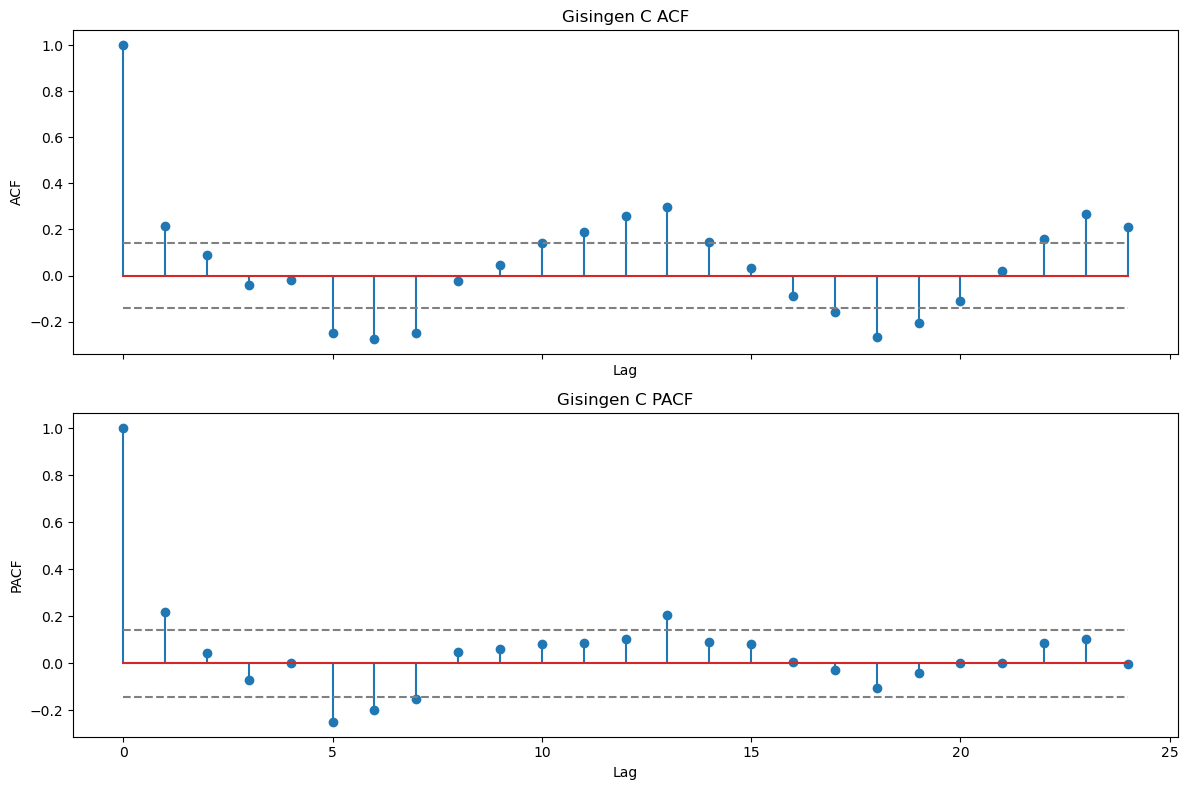

'Gisingen C'

,lag,acf,acf_lower,acf_upper,pacf,pacf_lower,pacf_upper
0,0,1.000000,-0.141451,0.141451,1.000000,-0.141451,0.141451
1,1,0.216161,-0.141451,0.141451,0.216161,-0.141451,0.141451
2,2,0.088420,-0.141451,0.141451,0.043738,-0.141451,0.141451
3,3,-0.039437,-0.141451,0.141451,-0.070595,-0.141451,0.141451
4,4,-0.017829,-0.141451,0.141451,0.000578,-0.141451,0.141451
5,5,-0.248797,-0.141451,0.141451,-0.249949,-0.141451,0.141451
6,6,-0.275165,-0.141451,0.141451,-0.197250,-0.141451,0.141451
7,7,-0.247759,-0.141451,0.141451,-0.150701,-0.141451,0.141451
8,8,-0.023464,-0.141451,0.141451,0.048960,-0.141451,0.141451
9,9,0.047757,-0.141451,0.141451,0.059728,-0.141451,0.141451


In [28]:
max_lag = 24

for key, series in detrended_series.items():
    variable, station = key.split('_', 1)
    n = len(series)
    conf = 1.96 / np.sqrt(n)
    acf_vals = acf(series, nlags=max_lag, fft=False, missing='drop')
    pacf_vals = pacf(series, nlags=max_lag, method='ywm')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    lags = np.arange(len(acf_vals))

    axes[0].stem(lags, acf_vals)
    axes[0].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
    axes[0].set_title(f'{station} {variable} ACF')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('ACF')

    axes[1].stem(lags, pacf_vals)
    axes[1].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
    axes[1].set_title(f'{station} {variable} PACF')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.show()

    acf_df = pd.DataFrame({
        'lag': lags,
        'acf': acf_vals,
        'acf_lower': -conf,
        'acf_upper': conf,
        'pacf': pacf_vals,
        'pacf_lower': -conf,
        'pacf_upper': conf,
    })
    display(f'{station} {variable}')
    display(acf_df.head(10))

# 2.2 AR and ARMA model fitting
This section fits AR and ARMA models to the detrended discharge (Q) and concentration (C) series for each station. The model orders are first selected based on the ACF and PACF plots (p from PACF cutoff, q from ACF cutoff), then fitted and compared using AIC and BIC. The chosen orders reflect the structure observed in the ACF/PACF plots.

In [29]:
def select_order_from_acf_pacf(series, max_lag=24):
    """
    Select ARMA(p,q) order based on ACF and PACF analysis.
    - p: lag where PACF first becomes insignificant after significant lags.
    - q: lag where ACF first becomes insignificant after significant lags.
    """
    n = len(series)
    conf = 1.96 / np.sqrt(n)
    
    acf_vals = acf(series, nlags=max_lag, fft=False, missing='drop')
    pacf_vals = pacf(series, nlags=max_lag, method='ywm')
    
    p = 0
    for lag in range(1, max_lag + 1):
        if abs(pacf_vals[lag]) > conf:
            p = lag
        else:
            break
    q = 0
    for lag in range(1, max_lag + 1):
        if abs(acf_vals[lag]) > conf:
            q = lag
        else:
            break
    
    return min(p, 3), min(q, 3)


def candidate_ar_arma_models(y, max_ar=3, max_ma=3):
    results = []
    y = np.asarray(y, dtype=float)
    if len(y) < 10:
        return pd.DataFrame(results, columns=['model', 'p', 'q', 'aic', 'bic'])

    for p in range(1, max_ar + 1):
        try:
            model = ARIMA(y, order=(p, 0, 0)).fit()
            results.append(('AR', p, 0, model.aic, model.bic))
        except Exception as e:
            print(f'AR({p}) fit failed: {e}')

    for p in range(1, max_ar + 1):
        for q in range(1, max_ma + 1):
            try:
                model = ARIMA(y, order=(p, 0, q)).fit()
                results.append(('ARMA', p, q, model.aic, model.bic))
            except Exception as e:
                print(f'ARMA({p},{q}) fit failed: {e}')

    return pd.DataFrame(results, columns=['model', 'p', 'q', 'aic', 'bic']).sort_values(['bic', 'aic'])

model_selection = {}
fitted_models = {}

for key, series in detrended_series.items():
    variable, station = key.split('_', 1)
    print(f'===== {station} {variable} =====')
    if len(series) < 10:
        print(f'Skipping {station} {variable}: too few detrended observations ({len(series)}) to fit AR/ARMA models.')
        continue

    p, q = select_order_from_acf_pacf(series, max_lag=24)
    print(f"Order suggested by ACF/PACF: p={p}, q={q}")

    selection = candidate_ar_arma_models(series, max_ar=3, max_ma=3)
    if selection.empty:
        print(f'No AR/ARMA model could be fitted for {station} {variable}.')
        continue
    display(selection.head(10))

    best_ar = selection[selection['q'] == 0].head(1)
    best_arma = selection[selection['q'] > 0].head(1)

    if not best_ar.empty:
        ar_p = int(best_ar['p'].iloc[0])
        ar_order = (ar_p, 0, 0)
        try:
            fitted_models[f'{key}_AR'] = ARIMA(series, order=ar_order).fit()
            print(f'Best AR by BIC: AR({ar_p},0) with AIC={best_ar.aic.iloc[0]:.1f} BIC={best_ar.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'Failed to fit AR({ar_p},0) for {station} {variable}: {e}')
    else:
        print(f'No AR candidate found for {station} {variable}.')

    if not best_arma.empty:
        arma_p = int(best_arma['p'].iloc[0])
        arma_q = int(best_arma['q'].iloc[0])
        arma_order = (arma_p, 0, arma_q)
        try:
            fitted_models[f'{key}_ARMA'] = ARIMA(series, order=arma_order).fit()
            print(f'Best ARMA by BIC: ARMA({arma_p},{arma_q}) with AIC={best_arma.aic.iloc[0]:.1f} BIC={best_arma.bic.iloc[0]:.1f}')
        except Exception as e:
            print(f'Failed to fit ARMA({arma_p},{arma_q}) for {station} {variable}: {e}')
    else:
        print(f'No ARMA candidate found for {station} {variable}.')

    print('')

print('Qualitative observations:')
print(' - Compare selected orders by station and variable. If the same order is selected for Q across stations, then the discharge dynamics may be similar.')
print(' - Different orders may indicate different flow persistence, catchment responses, or local controls.')
print(' - For C, similar model orders suggest similar solute transport dynamics, while different orders may reflect differing concentration processes or sampling periods.')
print(' - Compare Q and C orders within the same station: similar orders suggest correlated dynamics, different orders indicate independent processes.')

===== Diepoldsau Q =====
Order suggested by ACF/PACF: p=3, q=2


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-package

,model,p,q,aic,bic
8,ARMA,2,3,5788.570119,5818.169696
11,ARMA,3,3,5788.251993,5822.080081
6,ARMA,2,1,5911.554573,5932.697128
9,ARMA,3,1,5912.986196,5938.357262
10,ARMA,3,2,5911.347742,5940.947319
1,AR,2,0,5944.162417,5961.076461
2,AR,3,0,5941.060041,5962.202596
7,ARMA,2,2,5951.059373,5976.430439
3,ARMA,1,1,5960.424338,5977.338382
4,ARMA,1,2,5957.179703,5978.322258


Best AR by BIC: AR(2,0) with AIC=5944.2 BIC=5961.1


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Sylvie\anaconda3

,model,p,q,aic,bic
11,ARMA,3,3,-332.102720,-306.042757
8,ARMA,2,3,-312.876880,-290.074413
0,AR,1,0,-298.280958,-288.508471
1,AR,2,0,-296.657754,-283.627772
3,ARMA,1,1,-296.503111,-283.473129
4,ARMA,1,2,-297.510241,-281.222764
6,ARMA,2,1,-296.957150,-280.669673
2,AR,3,0,-295.596624,-279.309147
5,ARMA,1,3,-295.779238,-276.234266
7,ARMA,2,2,-295.512782,-275.967810


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

Best AR by BIC: AR(1,0) with AIC=-298.3 BIC=-288.5
Best ARMA by BIC: ARMA(3,3) with AIC=-332.1 BIC=-306.0

Qualitative observations:
 - Compare selected orders by station and variable. If the same order is selected for Q across stations, then the discharge dynamics may be similar.
 - Different orders may indicate different flow persistence, catchment responses, or local controls.
 - For C, similar model orders suggest similar solute transport dynamics, while different orders may reflect differing concentration processes or sampling periods.
 - Compare Q and C orders within the same station: similar orders suggest correlated dynamics, different orders indicate independent processes.


c:\Users\Sylvie\anaconda3\envs\WRM\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# 3. Timeseries application & evaluation
This section evaluates the fitted AR/ARMA models by comparing empirical and theoretical ACFs, analyzing residual autocorrelations, and testing for independence and normality of residuals.

===== Diepoldsau C Evaluation =====


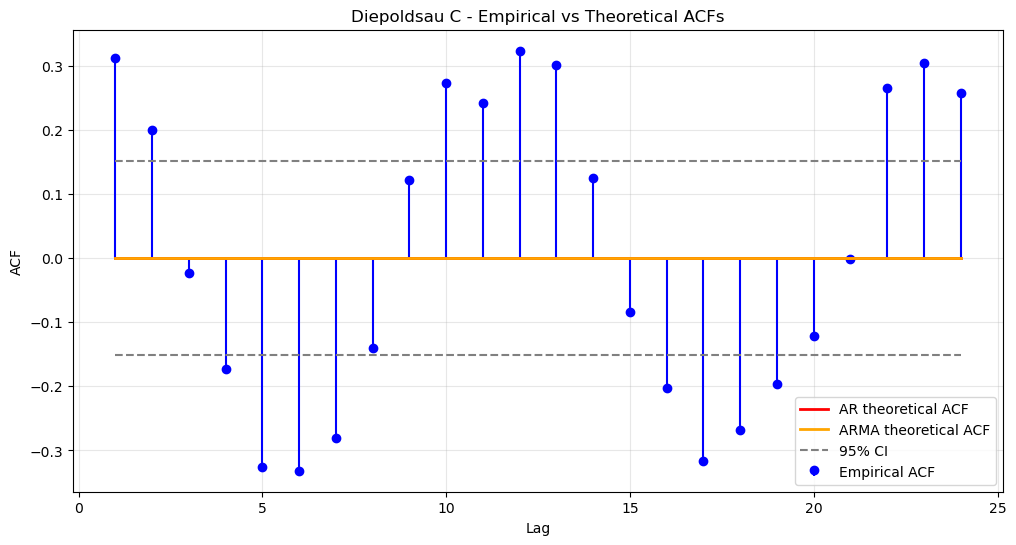

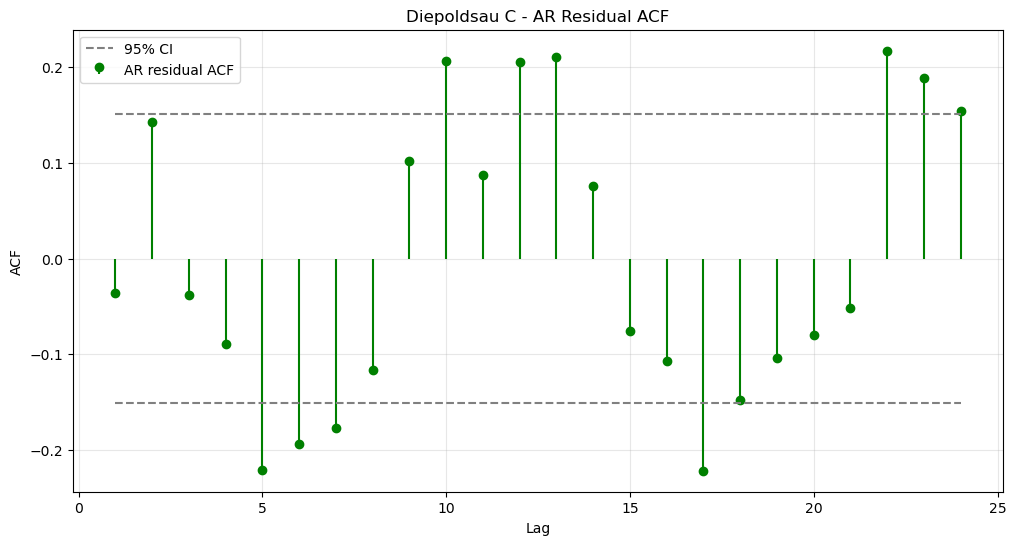

  AR residual ACF significant at lags: [5, 6, 7, 10, 12, 13, 17, 22, 23, 24]
  AR Ljung-Box lag 24: stat=98.18, p=0.0000
   -> Reject independence at 5% for AR residuals.


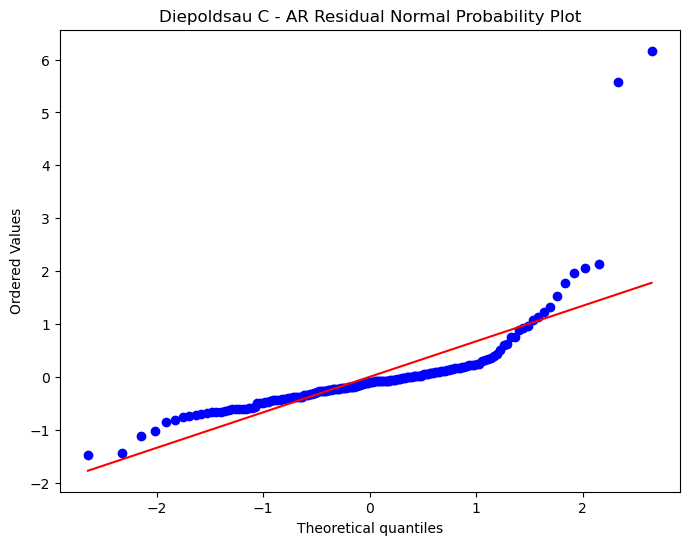

  AR PPCC: 0.7847


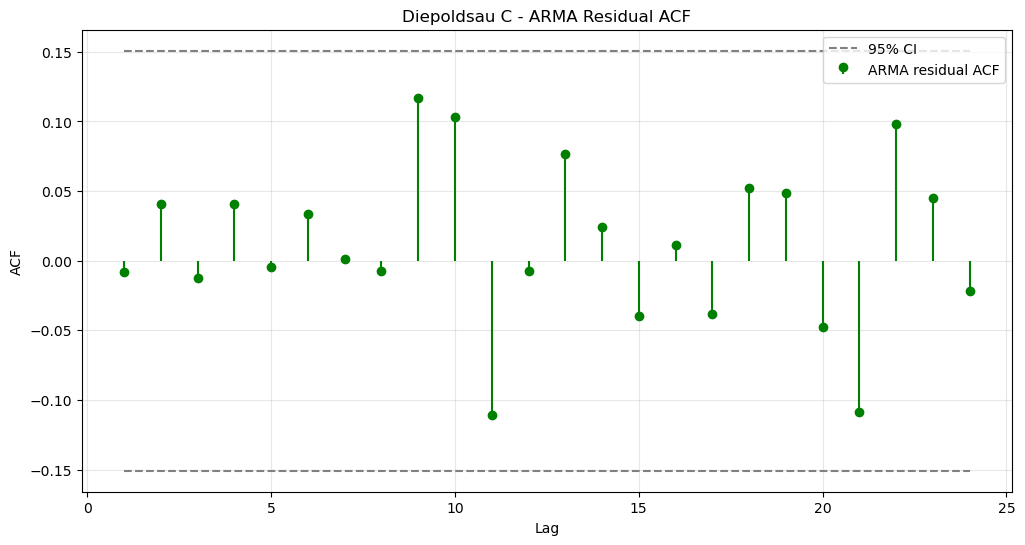

  ARMA residual ACF: no significant autocorrelations within 95% CI.
  ARMA Ljung-Box lag 24: stat=15.41, p=0.9083
   -> Fail to reject independence at 5% for ARMA residuals.


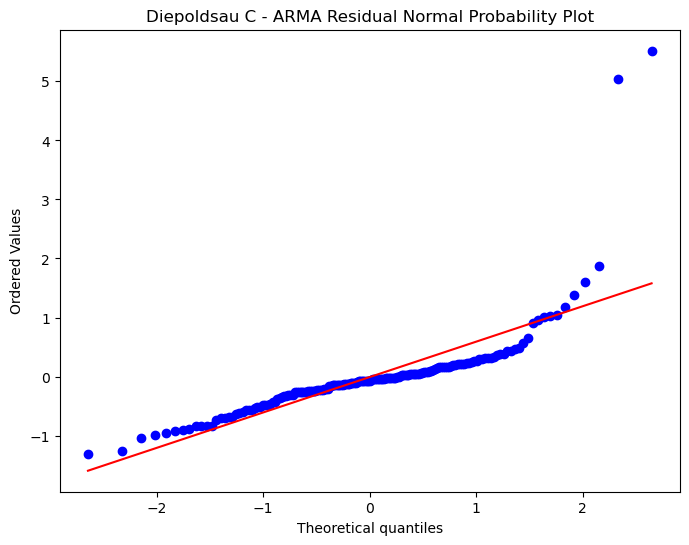

  ARMA PPCC: 0.7939

===== Gisingen C Evaluation =====


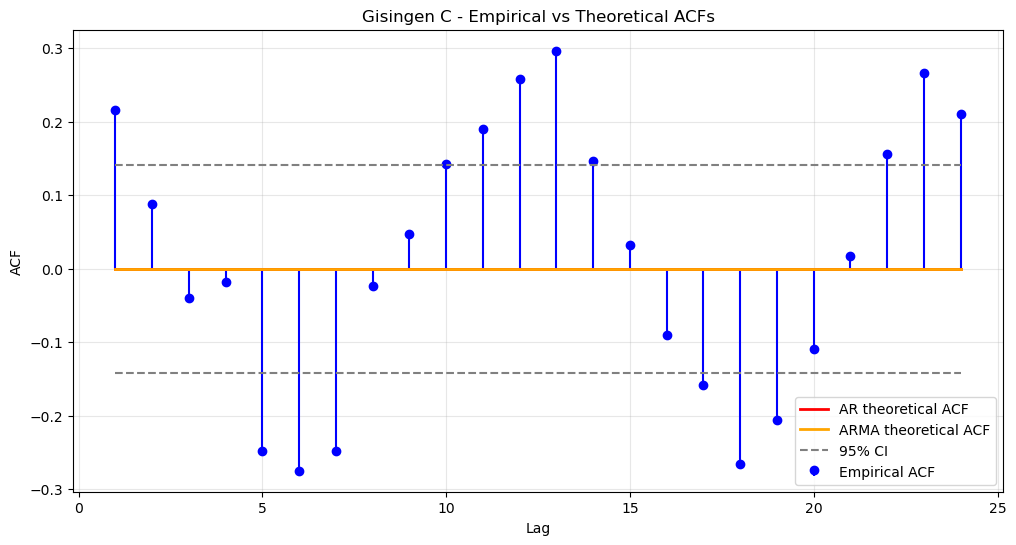

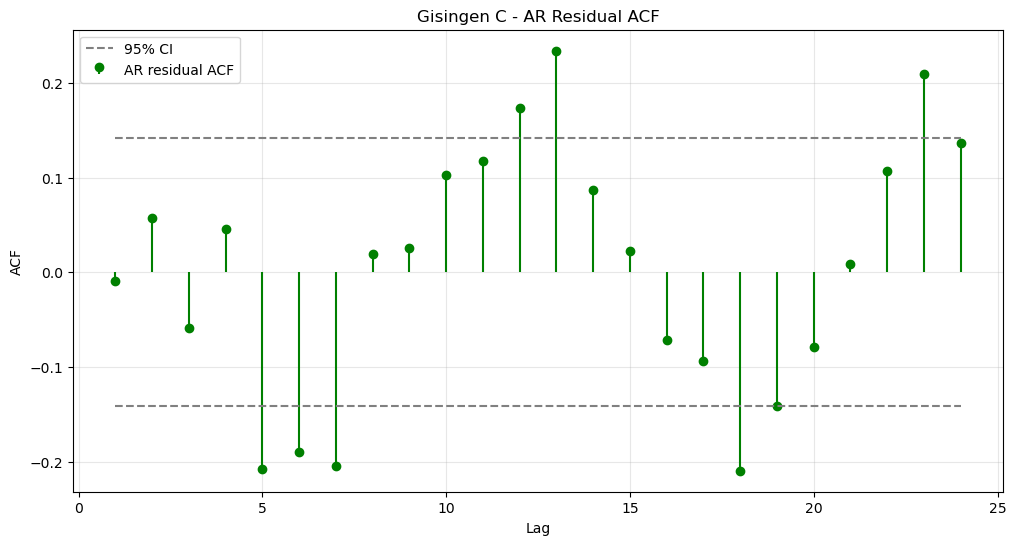

  AR residual ACF significant at lags: [5, 6, 7, 12, 13, 18, 23]
  AR Ljung-Box lag 24: stat=84.89, p=0.0000
   -> Reject independence at 5% for AR residuals.


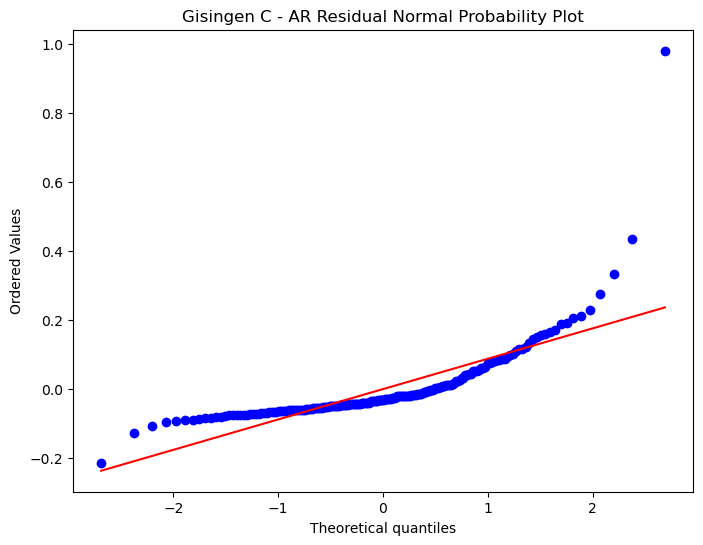

  AR PPCC: 0.7947


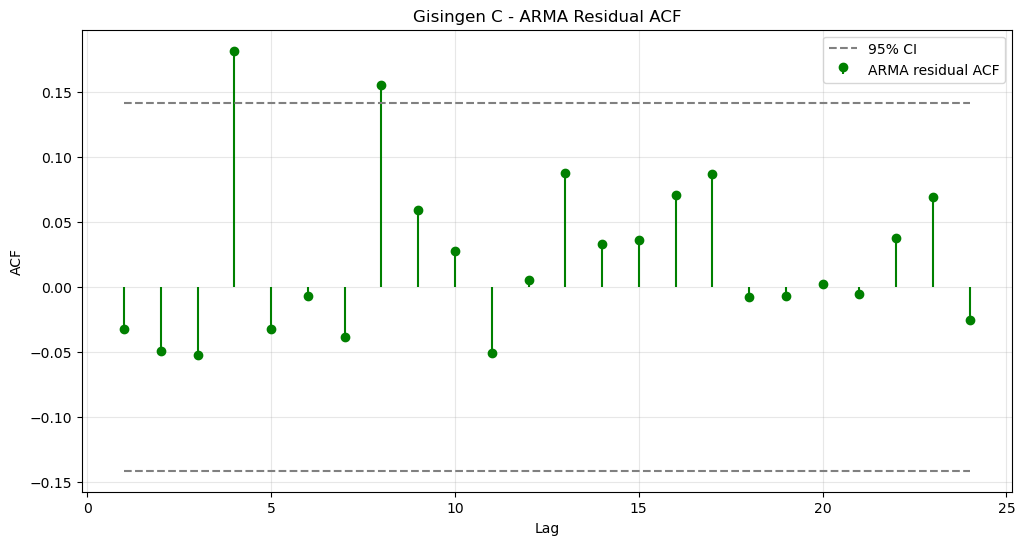

  ARMA residual ACF significant at lags: [4, 8]
  ARMA Ljung-Box lag 24: stat=20.76, p=0.6529
   -> Fail to reject independence at 5% for ARMA residuals.


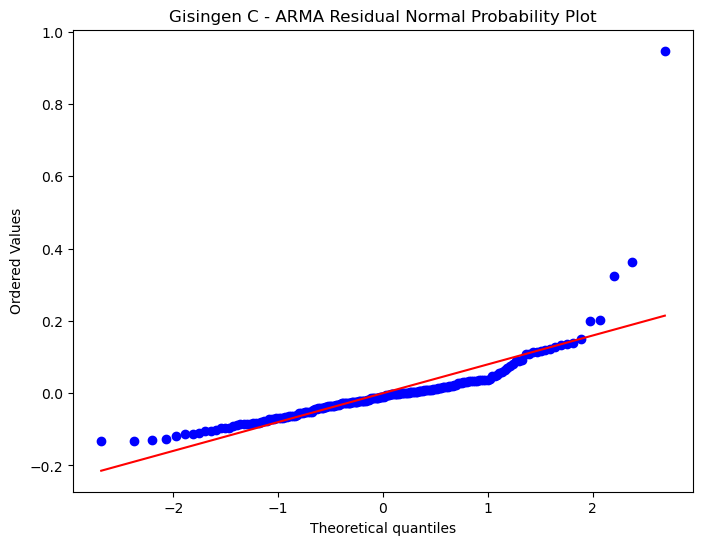

  ARMA PPCC: 0.7991

===== Diepoldsau Q Evaluation =====


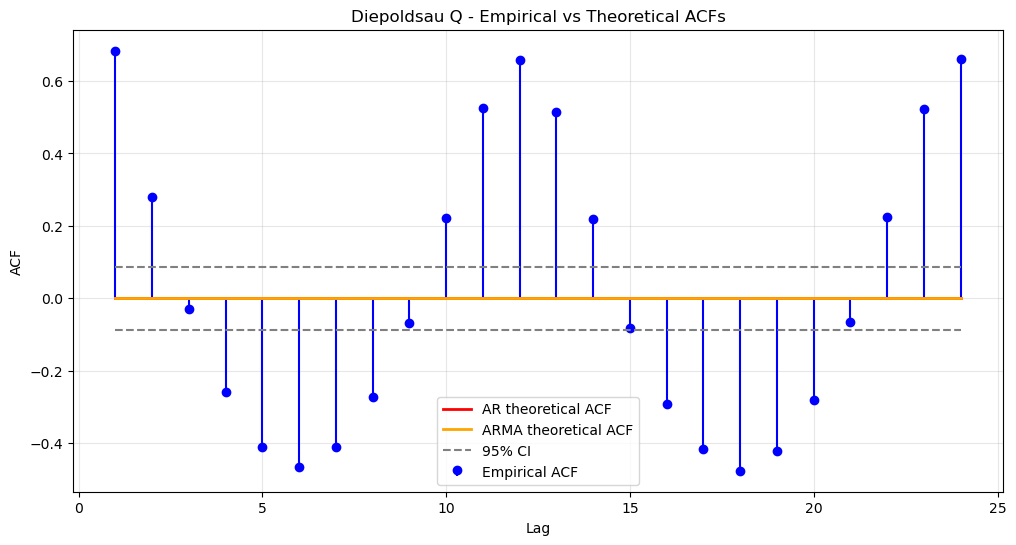

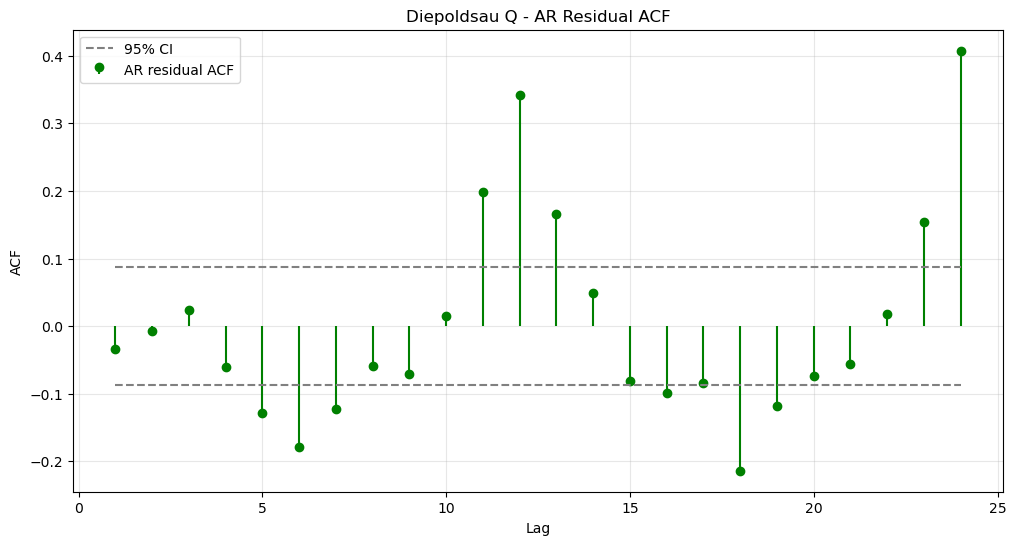

  AR residual ACF significant at lags: [5, 6, 7, 11, 12, 13, 16, 18, 19, 23, 24]
  AR Ljung-Box lag 24: stat=286.65, p=0.0000
   -> Reject independence at 5% for AR residuals.


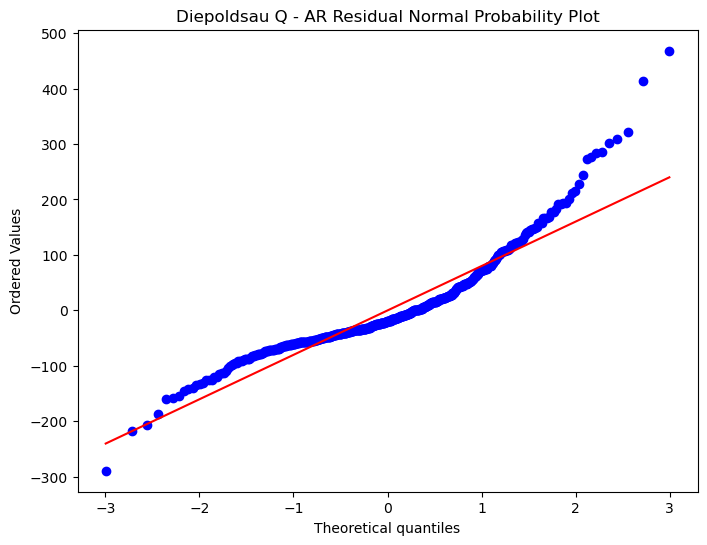

  AR PPCC: 0.9443


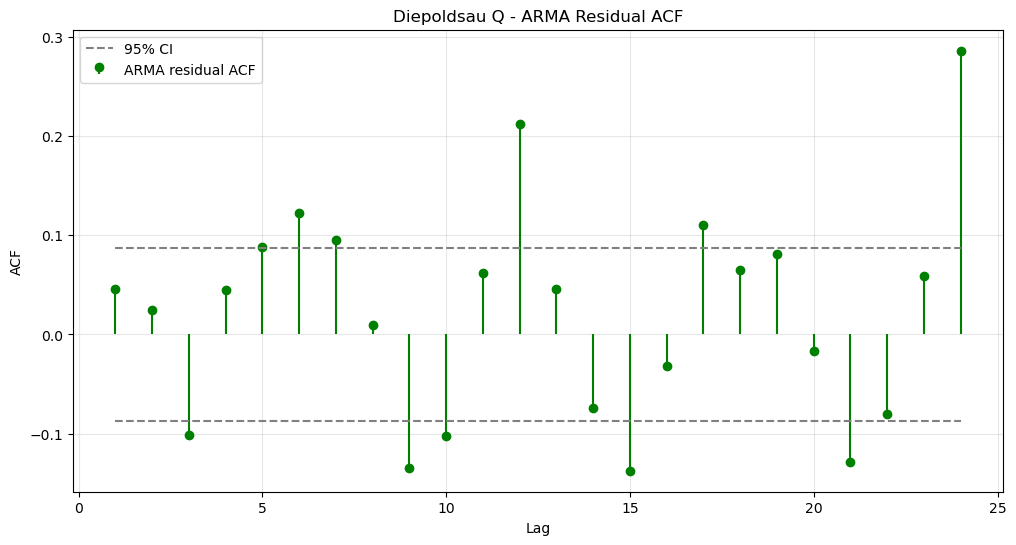

  ARMA residual ACF significant at lags: [3, 5, 6, 7, 9, 10, 12, 15, 17, 21, 24]
  ARMA Ljung-Box lag 24: stat=148.75, p=0.0000
   -> Reject independence at 5% for ARMA residuals.


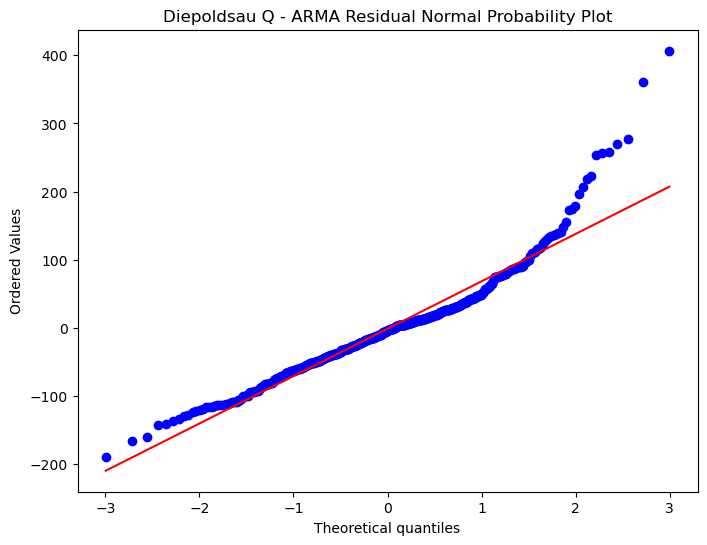

  ARMA PPCC: 0.9622

===== Gisingen Q Evaluation =====


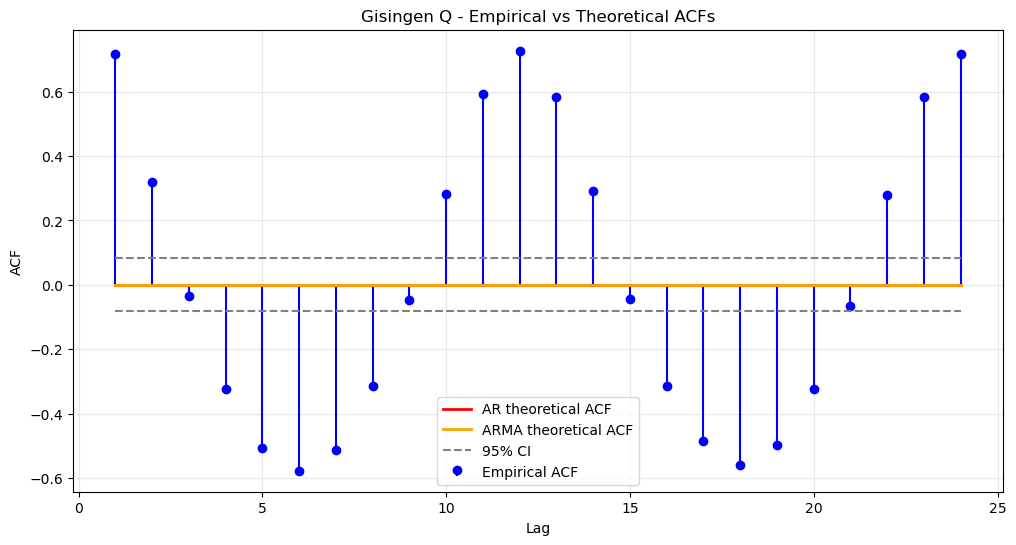

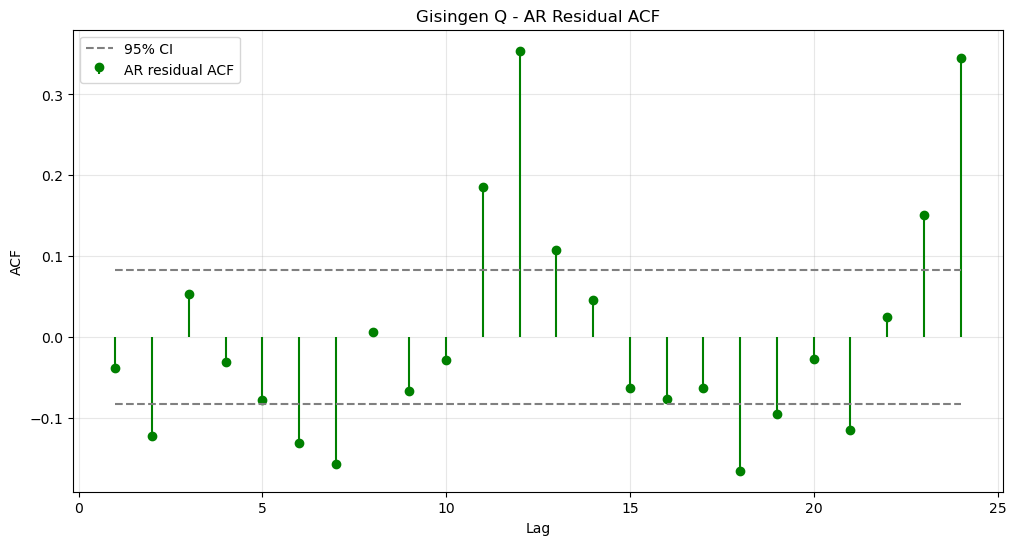

  AR residual ACF significant at lags: [2, 6, 7, 11, 12, 13, 18, 19, 21, 23, 24]
  AR Ljung-Box lag 24: stat=264.48, p=0.0000
   -> Reject independence at 5% for AR residuals.


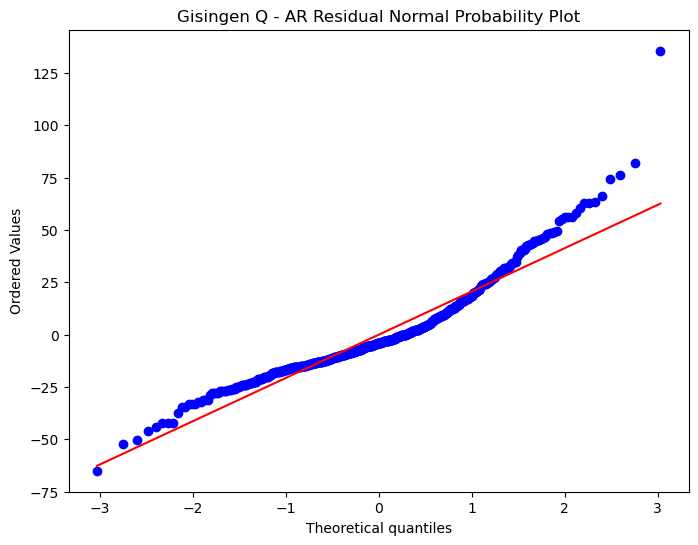

  AR PPCC: 0.9584


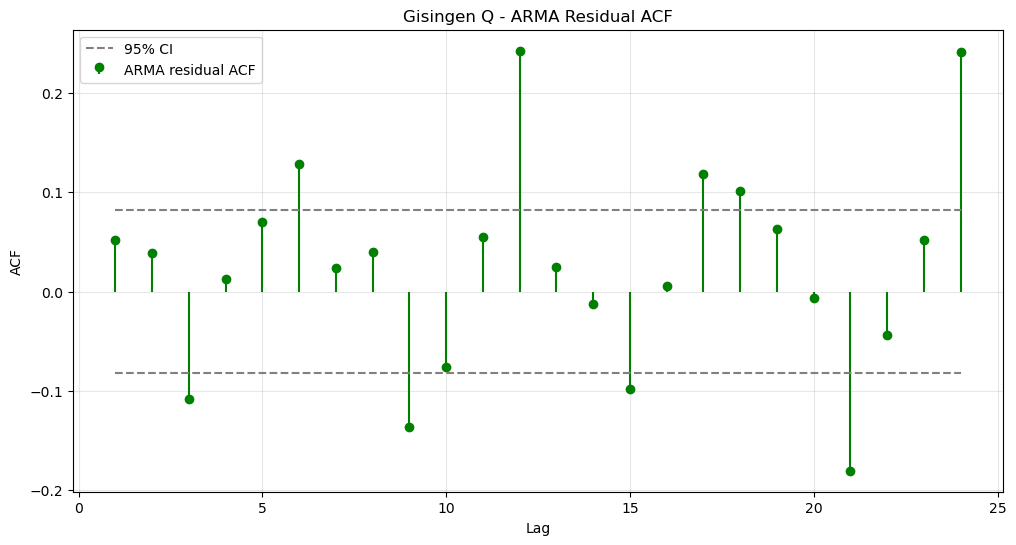

  ARMA residual ACF significant at lags: [3, 6, 9, 12, 15, 17, 18, 21, 24]
  ARMA Ljung-Box lag 24: stat=151.25, p=0.0000
   -> Reject independence at 5% for ARMA residuals.


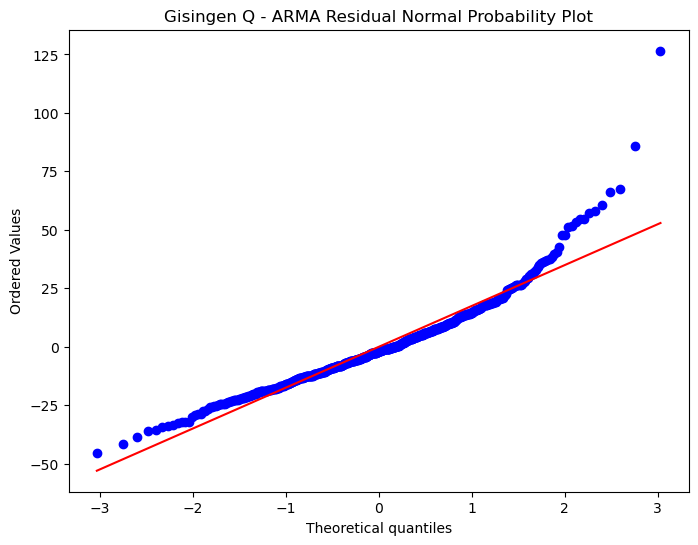

  ARMA PPCC: 0.9605



In [30]:
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot
import numpy as np

max_lag = 24
series_keys = sorted(detrended_series.keys())

for series_key in series_keys:
    if '_' in series_key:
        variable, station = series_key.split('_', 1)
    else:
        variable = series_key
        station = ''
    series = detrended_series[series_key]
    n = len(series)
    conf = 1.96 / np.sqrt(n)
    emp_acf = acf(series, nlags=max_lag, fft=False, missing='drop')
    
    ar_model = fitted_models.get(f'{series_key}_AR')
    arma_model = fitted_models.get(f'{series_key}_ARMA')

    print(f'===== {station} {variable} Evaluation =====')

    fig, ax = plt.subplots(figsize=(12, 6))
    lags = np.arange(1, max_lag + 1)
    ax.stem(lags, emp_acf[1:], label='Empirical ACF', linefmt='b-', markerfmt='bo', basefmt=' ')

    if ar_model is not None:
        try:
            theo_ar = ar_model.acf(max_lag + 1)[1:]
        except Exception:
            theo_ar = np.zeros(max_lag)
        ax.plot(lags, theo_ar, label='AR theoretical ACF', color='red', linewidth=2)
    else:
        print('  No AR model available for empirical/theoretical ACF comparison.')

    if arma_model is not None:
        try:
            theo_arma = arma_model.acf(max_lag + 1)[1:]
        except Exception:
            theo_arma = np.zeros(max_lag)
        ax.plot(lags, theo_arma, label='ARMA theoretical ACF', color='orange', linewidth=2)
    else:
        print('  No ARMA model available for empirical/theoretical ACF comparison.')

    ax.hlines([conf, -conf], 1, max_lag, colors='gray', linestyles='dashed', label='95% CI')
    ax.set_title(f'{station} {variable} - Empirical vs Theoretical ACFs')
    ax.set_xlabel('Lag')
    ax.set_ylabel('ACF')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    for model_type, model_obj in [('AR', ar_model), ('ARMA', arma_model)]:
        if model_obj is None:
            continue
        residuals = model_obj.resid
        res_acf = acf(residuals, nlags=max_lag, fft=False, missing='drop')

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.stem(lags, res_acf[1:], label=f'{model_type} residual ACF', linefmt='g-', markerfmt='go', basefmt=' ')
        ax.hlines([conf, -conf], 1, max_lag, colors='gray', linestyles='dashed', label='95% CI')
        ax.set_title(f'{station} {variable} - {model_type} Residual ACF')
        ax.set_xlabel('Lag')
        ax.set_ylabel('ACF')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

        significant_lags = [lag for lag in range(1, max_lag + 1) if abs(res_acf[lag]) > conf]
        if significant_lags:
            print(f'  {model_type} residual ACF significant at lags: {significant_lags}')
        else:
            print(f'  {model_type} residual ACF: no significant autocorrelations within 95% CI.')

        lb_test = acorr_ljungbox(residuals, lags=[max_lag], return_df=True)
        lb_stat = lb_test['lb_stat'].iloc[0]
        lb_pval = lb_test['lb_pvalue'].iloc[0]
        print(f'  {model_type} Ljung-Box lag {max_lag}: stat={lb_stat:.2f}, p={lb_pval:.4f}')
        if lb_pval < 0.05:
            print(f'   -> Reject independence at 5% for {model_type} residuals.')
        else:
            print(f'   -> Fail to reject independence at 5% for {model_type} residuals.')

        fig, ax = plt.subplots(figsize=(8, 6))
        (osm, osr), (_, _, r) = probplot(residuals, plot=ax)
        ax.set_title(f'{station} {variable} - {model_type} Residual Normal Probability Plot')
        plt.show()
        print(f'  {model_type} PPCC: {r:.4f}')

    print('')